In [2]:

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns   
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, brier_score_loss

#Set plot style
sns.set_theme(style="whitegrid")
%matplotlib inline


In [3]:
#Load the dataset
df = pd.read_csv('Task 3 and 4_Loan_Data.csv')

#Display basic info and first few rows
print("--- Dataset Info ---")
print(df.info())
print("\n--- Summary Statistics ---")
print(df.describe())

#Check target variable balance
print("\n--- Default Distribution ---")
print(df['default'].value_counts(normalize=True))


--- Dataset Info ---
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               10000 non-null  int64  
 1   credit_lines_outstanding  10000 non-null  int64  
 2   loan_amt_outstanding      10000 non-null  float64
 3   total_debt_outstanding    10000 non-null  float64
 4   income                    10000 non-null  float64
 5   years_employed            10000 non-null  int64  
 6   fico_score                10000 non-null  int64  
 7   default                   10000 non-null  int64  
dtypes: float64(3), int64(5)
memory usage: 625.1 KB
None

--- Summary Statistics ---
        customer_id  credit_lines_outstanding  loan_amt_outstanding  \
count  1.000000e+04              10000.000000          10000.000000   
mean   4.974577e+06                  1.461200           4159.677034   
std    2.293890e+06                

In [4]:
# Define features and target variable
# 'customer_id' is excluded as it is a unique identifier 
feature_cols =['credit_lines_outstanding', 'loan_amt_outstanding', 'total_debt_outstanding', 'income', 'years_employed', 'fico_score']

X = df[feature_cols]
y = df['default']

#Split into training and testing sets(80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale features (critical for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")


Training set shape: (8000, 6)
Testing set shape: (2000, 6)


=== Logistic Regression Performance ===
ROC AUC Score: 1.0000
Brier Score (Calibration): 0.0028

=== Random Forest Performance ===
ROC AUC Score: 0.9999
Brier Score (Calibration): 0.0040


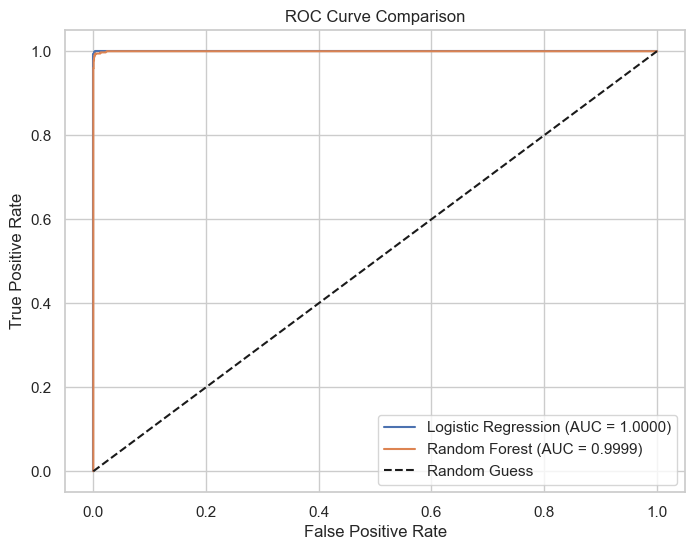

In [5]:
# 1. Logistic Regression Model
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)
lr_probs = lr_model.predict_proba(X_test_scaled)[:, 1]

# 2. Random Forest Model
rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model.fit(X_train, y_train)  # Tree models don't strictly require scaling
rf_probs = rf_model.predict_proba(X_test)[:, 1]

# Comparative Performance Evaluation
print("=== Logistic Regression Performance ===")
print(f"ROC AUC Score: {roc_auc_score(y_test, lr_probs):.4f}")
print(f"Brier Score (Calibration): {brier_score_loss(y_test, lr_probs):.4f}")

print("\n=== Random Forest Performance ===")
print(f"ROC AUC Score: {roc_auc_score(y_test, rf_probs):.4f}")
print(f"Brier Score (Calibration): {brier_score_loss(y_test, rf_probs):.4f}")

# Plot ROC Curves
plt.figure(figsize=(8, 6))
for probs, label in zip([lr_probs, rf_probs], ['Logistic Regression', 'Random Forest']):
    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.plot(fpr, tpr, label=f'{label} (AUC = {roc_auc_score(y_test, probs):.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

In [6]:
# We'll use the Logistic Regression model for the final function 
# as it naturally outputs highly calibrated, smooth probabilities.

def calculate_expected_loss(credit_lines, loan_amt, total_debt, income, years_employed, fico, recovery_rate=0.10):
    """""
    Calculates the Expected Loss (EL) on a loan.
    Formula: Expected Loss = Loan Amount * PD * (1 - Recovery Rate)
    Where (1 - Recovery Rate) is Loss Given Default (LGD).
    """
    # 1. Format the input vector matching the exact order of features
    input_data = np.array([[credit_lines, loan_amt, total_debt, income, years_employed, fico]])
    
    # 2. Scale features using the fitted scaler instance
    input_scaled = scaler.transform(input_data)
    
    # 3. Predict Probability of Default (PD)
    pd_probability = lr_model.predict_proba(input_scaled)[0, 1]
    
    # 4. Define Loss Given Default (LGD)
    lgd = 1.0 - recovery_rate
    
    # 5. Calculate Expected Loss (EL)
    expected_loss = loan_amt * pd_probability * lgd
    
    return {
        "Probability of Default (PD)": f"{pd_probability * 100:.2f}%",
        "Loss Given Default (LGD)": f"{lgd * 100:.2f}%",
        "Expected Loss ($)": round(expected_loss, 2)
    }

# --- Test Case Example ---
# High risk example profile: Multiple credit lines, high debt, low FICO
sample_el = calculate_expected_loss(
    credit_lines=5, 
    loan_amt=2000.0, 
    total_debt=8500.0, 
    income=25000.0, 
    years_employed=1, 
    fico=550
)

print("--- Expected Loss Assessment Example ---")
for key, value in sample_el.items():
    print(f"{key}: {value}")

--- Expected Loss Assessment Example ---
Probability of Default (PD): 100.00%
Loss Given Default (LGD): 90.00%
Expected Loss ($): 1800.0


C:\Users\abuha\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
